In [1]:
# Reproducibility

import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [2]:
#Load the dataset

import pandas as pd
from pathlib import Path

# Set project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "annotated_data" / "final_annotated_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (2000, 14)


,text,topic,sentiment,annotator,confidence,match_key,match_text,source,date,channel,product,language,clean_text,match_score
0,i am writing to seek urgent assistance regardi...,Mobile Banking App,negative,annotator_1,high,i am writing to seek urgent assistance regardi...,i am writing to seek urgent assistance regardi...,CRM Tool,04/11/2025 00:00,Service Email,Mobile,english,i am writing to seek urgent assistance regardi...,99.737877
1,name seem to neglect your duty to give the bes...,Mobile Banking App,negative,annotator_1,high,name seem to neglect your duty to give the bes...,name seem to neglect your duty to give the bes...,CRM Tool,05/11/2025 00:00,Service Email,Mobile,english,seem to neglect your duty to give the best bec...,98.245614
2,namere seeking your assistance in providing ...,Payments,negative,annotator_1,high,namere seeking your assistance in providing a ...,namere seeking your assistance in providing a ...,CRM Tool,05/12/2025 00:00,Service Email,Thunes,english,namere seeking your assistance in providing a ...,88.442623
3,reminder on resolving this issue of payment ...,Acccount Issues,negative,annotator_1,high,reminder on resolving this issue of payment on...,reminder on resolving this issue of payment on...,CRM Tool,19/11/2025 00:00,Service Email,Card Online Disputes,english,name name reminder on resolving this issue of ...,97.071130
4,a member of you service and am trying to open...,Mobile Banking App,negative,annotator_1,high,a member of you service and am trying to open ...,a member of you service and am trying to open ...,CRM Tool,25/11/2025 00:00,Service Email,Mobile,english,namename a member of you service and am trying...,97.352342


In [3]:
# Select only the relevant columns and drop rows with missing values

df_model = df[['clean_text','sentiment']]

df_model = df_model.dropna()

print(df_model.shape)

(2000, 2)


In [4]:
# Encode the labels to numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_model['sentiment_encoded'] = le.fit_transform(df_model['sentiment'])

df_model.head()

,clean_text,sentiment,sentiment_encoded
0,i am writing to seek urgent assistance regardi...,negative,0
1,seem to neglect your duty to give the best bec...,negative,0
2,namere seeking your assistance in providing a ...,negative,0
3,name name reminder on resolving this issue of ...,negative,0
4,namename a member of you service and am trying...,negative,0


In [5]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X = df_model['clean_text']
y = df_model['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 1600
Test: 400


In [6]:
# Vectorize the text data using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(1600, 5000)


In [7]:
# Train baseline model using Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
# Predict on the test set

y_pred = model.predict(X_test_tfidf)

In [9]:
# Evaluate the model

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.84


In [10]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       201
           1       0.89      0.74      0.81       161
           2       0.97      0.84      0.90        38

    accuracy                           0.84       400
   macro avg       0.88      0.83      0.85       400
weighted avg       0.85      0.84      0.84       400



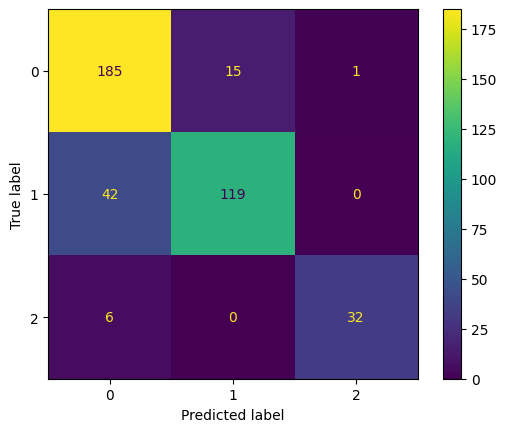

In [11]:
# Confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [12]:
# Save the baseline model using pickle

import pickle

MODEL_PATH = PROJECT_ROOT / "models" / "logistic_regression_baseline_model.pkl"

MODEL_PATH.parent.mkdir(exist_ok=True)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)

print("Model saved")

Model saved


In [13]:
# Save the results

results = pd.DataFrame({
    "text": X_test,
    "Actual": y_test,
    "Predicted": y_pred
})

OUTPUT_PATH = PROJECT_ROOT / "results"

OUTPUT_PATH.mkdir(exist_ok=True)

results.to_csv(
    OUTPUT_PATH / "logistic_regression_results.csv",
    index=False
)

print("Results saved")

Results saved
